In [1]:
import sys
print(sys.executable) 

D:\anacccoda\envs\isro_env\python.exe


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TF Version:", tf.__version__)
print("Setup Ready!")

TF Version: 2.10.0
Setup Ready!


In [4]:
import os

# Sahi path
dataset_path = r"D:\ML projects\archive\EuroSAT_RGB"

# Folders dekho
classes = os.listdir(dataset_path)
print("Total Classes:", len(classes))
print("\nClasses:")
for c in classes:
    count = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"  {c}: {count} images")

Total Classes: 10

Classes:
  AnnualCrop: 3000 images
  Forest: 3000 images
  HerbaceousVegetation: 3000 images
  Highway: 2500 images
  Industrial: 2500 images
  Pasture: 2000 images
  PermanentCrop: 2500 images
  Residential: 3000 images
  River: 2500 images
  SeaLake: 3000 images


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27924\4064826761.py:19: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\anacccoda\envs\isro_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


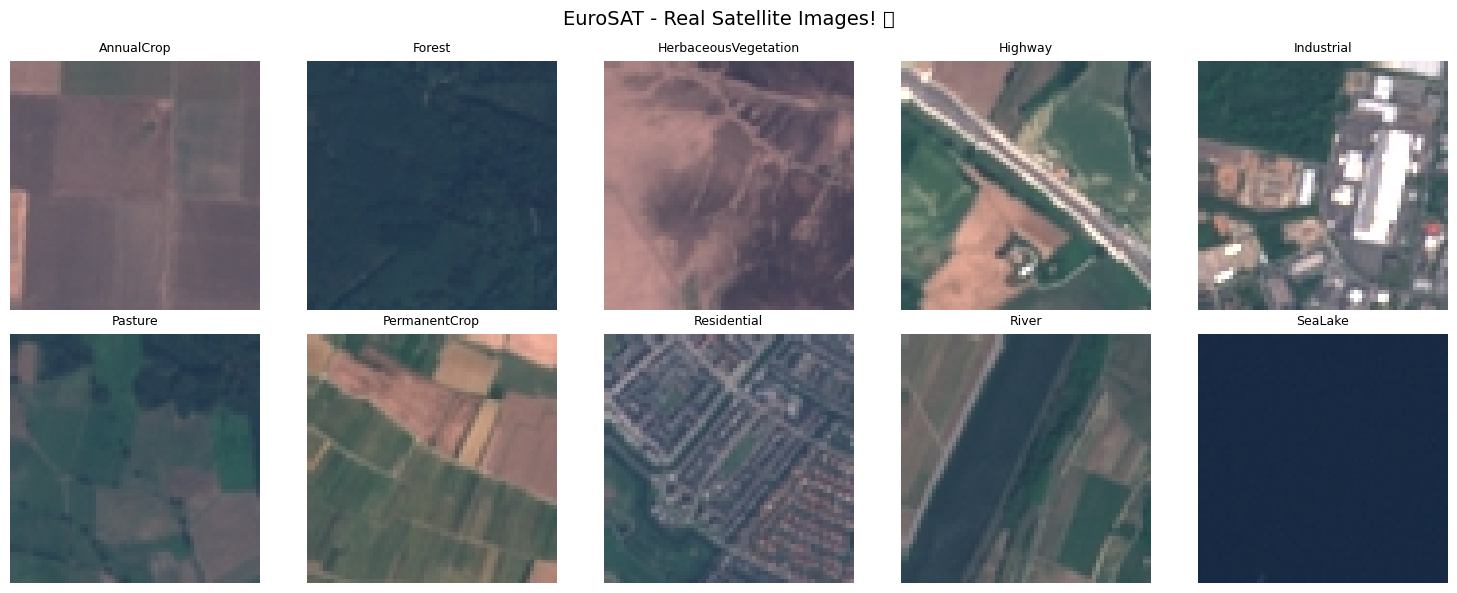

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, class_name in enumerate(classes):
    # Har class ki pehli image lo
    class_path = os.path.join(dataset_path, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    img = mpimg.imread(img_path)
    
    axes[i//5, i%5].imshow(img)
    axes[i//5, i%5].set_title(class_name, fontsize=9)
    axes[i//5, i%5].axis('off')

plt.suptitle("EuroSAT - Real Satellite Images! 🛰️", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data load karna — 80% train, 20% test
datagen = ImageDataGenerator(
    rescale=1./255,        # Pixels 0-255 ko 0-1 mein convert karo
    validation_split=0.2   # 20% test ke liye
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),  # Har image 64x64 resize hogi
    batch_size=32,
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    subset='validation'
)

print("Train images:", train_data.samples)
print("Val images:", val_data.samples)
print("Classes:", train_data.class_indices)


Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
Train images: 21600
Val images: 5400
Classes: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Block 1 - Simple edges dhundega
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    # Block 2 - Complex shapes dhundega
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Block 3 - Aur complex patterns
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Classification
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 satellite classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6, 6, 128)        0

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)

print("Training Complete! 🎉")

Epoch 1/15
675/675 [==============================] - 302s 446ms/step - loss: 1.4564 - accuracy: 0.4376 - val_loss: 1.0118 - val_accuracy: 0.6463
Epoch 2/15
675/675 [==============================] - 48s 71ms/step - loss: 0.9656 - accuracy: 0.6593 - val_loss: 0.8119 - val_accuracy: 0.7043
Epoch 3/15
675/675 [==============================] - 50s 74ms/step - loss: 0.7962 - accuracy: 0.7143 - val_loss: 0.7441 - val_accuracy: 0.7198
Epoch 4/15
675/675 [==============================] - 50s 73ms/step - loss: 0.6999 - accuracy: 0.7546 - val_loss: 0.6424 - val_accuracy: 0.7678
Epoch 5/15
675/675 [==============================] - 52s 77ms/step - loss: 0.6317 - accuracy: 0.7780 - val_loss: 0.5659 - val_accuracy: 0.7991
Epoch 6/15
675/675 [==============================] - 52s 76ms/step - loss: 0.5719 - accuracy: 0.7967 - val_loss: 0.5504 - val_accuracy: 0.7996
Epoch 7/15
675/675 [==============================] - 49s 73ms/step - loss: 0.5336 - accuracy: 0.8133 - val_loss: 0.4943 - val_accurac

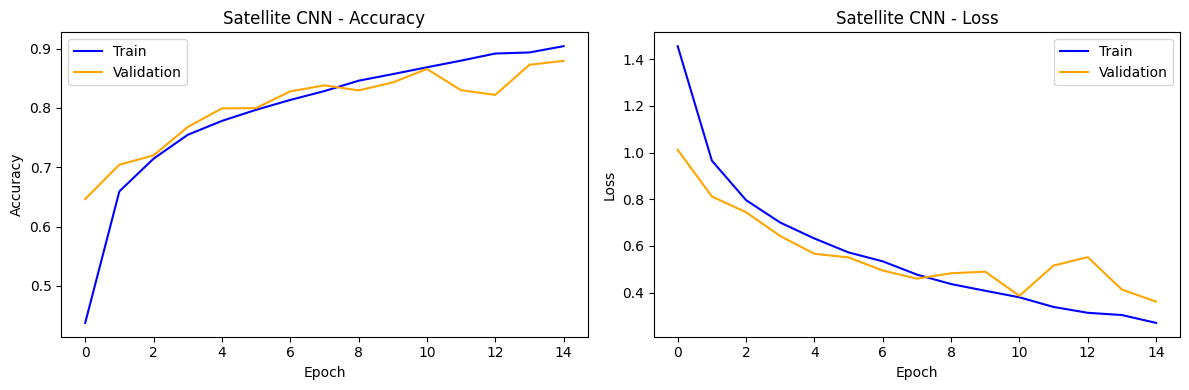

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 
         label='Train', color='blue')
plt.plot(history.history['val_accuracy'], 
         label='Validation', color='orange')
plt.title('Satellite CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 
         label='Train', color='blue')
plt.plot(history.history['val_loss'], 
         label='Validation', color='orange')
plt.title('Satellite CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
model.save('D:/ML_Projects/ISRO_Satellite_CNN.h5')
print("Model saved! 💾")
print("File: ISRO_Satellite_CNN.h5")

Model saved! 💾
File: ISRO_Satellite_CNN.h5


In [11]:
import os
print("Current folder:", os.getcwd())

Current folder: C:\Users\Lenovo
